In [1]:
from functions.internal import load_dataset, normalization, extract_timeseries, visualize_graph_internal
from functions.SQUIC_functions import squic_fit_matrix_computation, squic_fit_computation
from functions.clustering_functions import clustering_2_communities, ARI_fscore, plot_ARI_f1, study_CC
import matplotlib.pyplot as plt
import json
from scipy import sparse
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
import os
import networkx as nx

In [2]:
def ask_yes_no(prompt, default=None):
    """
    Ask the user a yes/no question with optional default.
    """
    while True:
        answer = input(f"{prompt} (Y/N) ").strip().upper()
        if not answer and default:
            return default
        if answer in ['Y', 'N']:
            return answer
        print("Please enter 'Y' or 'N'.")


def ask_input(prompt, default=None):
    """
    Ask the user for input with optional default.
    """
    answer = input(f"{prompt} ").strip()
    if not answer and default is not None:
        return default
    return answer

Please enter 'Y' or 'N'.
Head of Y_norm df:
          0         1         2         3         4         5         6  \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.021057  0.054107  0.054107  0.054107  0.054107  0.054107  0.054107   
2  0.145583  0.217017  0.217017  0.217017  0.217017  0.217017  0.217017   
3  0.000063  0.000063  0.000063  0.000063  0.000063  0.000063  0.000063   
4  0.000060  0.000060  0.000060  0.000060  0.000060  0.000060  0.000060   

          7         8         9  ...       355       356       357       358  \
0  0.000000  0.000000  0.000000  ...  2.928368  2.934959  2.952739  2.952739   
1  0.054107  0.054107  0.237593  ...  2.319709  2.319709  2.319697  2.178234   
2  0.217017  0.498930  0.736953  ...  2.744306  2.842049  2.841268  2.927821   
3  0.000063  0.215060  0.282816  ...  4.081573  4.081573  4.032990  4.032990   
4  0.000060  0.856894  1.758480  ...  4.367516  4.563064  4.346059  4.908558   

        359       360   

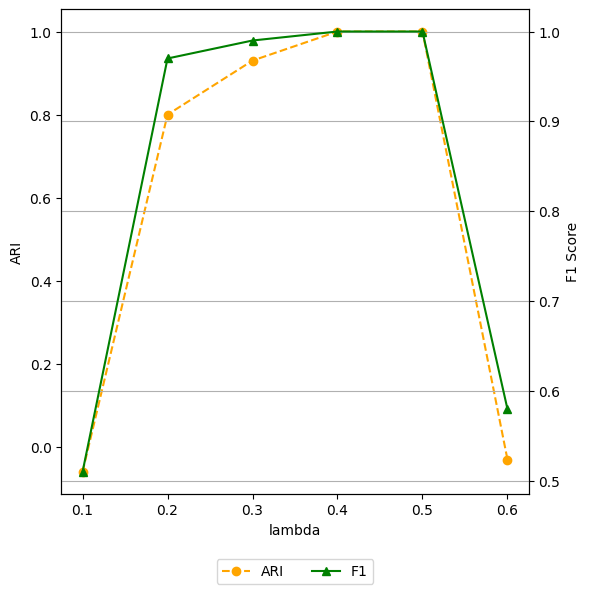

In [3]:
'''
This script allows you to **load previously cached data** to speed up subsequent runs. 
Specifically, it can load:
- `Y_normalized` (the normalized dataset)
- `knn_matrix` (the nearest neighbors matrix)
- `account_prop` (the account properties)

These files are expected to be stored in the `paysim_data_saved` directory, named with the 
corresponding dataset dimension.

Note:
- The data must have been saved from a **previous successful run** using the same dimension.
- On the **first run** for a given dimension, you must generate and save this data by answering 
    "Y" when prompted to cache it.
'''
user_input = ask_yes_no("\nDo you want to load data?")

if user_input == 'Y':
    dimension = ask_input("Which dimension (100/1K/10K/100K/1M)?").upper()
    path = 'paysim_data_saved'

    try:
        # Load pre-saved Y_norm
        chunk_size = 10000
        chunks = []

        for chunk in pd.read_csv(f'{path}/YNorm_{dimension}.csv', chunksize=chunk_size):
            chunks.append(chunk)

        Y_norm = pd.concat(chunks, ignore_index=True)
        print(f"Head of Y_norm df:")
        print(Y_norm.head())

        print(f"\ndimension of YNorm loaded: {Y_norm.shape}")

        std_dev = round(np.mean(np.std(Y_norm, axis=1)), 2)

        if not(std_dev > 0.9 and std_dev <= 1):
            print("Mean std per row (should be 1):", std_dev)
            print("Max:", np.max(Y_norm))
            print("Min:", np.min(Y_norm))

            # Step 1: Convert DataFrame to NumPy array for performance
            Y = Y_norm.to_numpy()  # shape: (num_users, num_days)

            # Step 2: Compute row-wise standard deviation
            stds = np.std(Y, axis=1)
            safe_stds = np.clip(stds, 1e-8, None)  # Avoid division by near-zero

            # Step 3: Normalize each row by its std using broadcasting
            Y = Y / safe_stds[:, np.newaxis]

            Y_norm = pd.DataFrame(Y, index=Y_norm.index, columns=Y_norm.columns)

            print(f"Head of Y_norm df:")
            print(Y_norm.head())

            print("Mean std after normalization (should be ~1):", np.mean(np.std(Y_norm, axis=1)))
            print("Max:", np.max(Y_norm))
            print("Min:", np.min(Y_norm))
        else:
            print("Mean std per row (should be 1):", std_dev)

        # Load pre-saved knn_matrix
        knn_matrix = sparse.load_npz(f'{path}/knn_matrix_{dimension}.npz')

        if dimension == '1M':
            # Remove self-loops
            knn_matrix.setdiag(0)
            knn_matrix.eliminate_zeros()

        print("Shape KNN:", knn_matrix.shape)
        print("Non-zeros KNN:", knn_matrix.nnz)
        
        # Load pre-saved account_properties
        with open(f'{path}/account_prop_{dimension}.json', 'r') as f:
            account_prop = json.load(f)

        account_prop = {int(k): v for k, v in account_prop.items()}
        
        name = 'PAYSIM'

    except Exception as e:
        # If data are not present
        print(f"Error loading data: {e}")
        exit(1)
    
else: # Normal run
    Y, name, dimension, account_prop = load_dataset()

    # extract_timeseries(Y, name, dimension)

    Y_norm = normalization(Y, name)

    # Y = Y.T.values

    # # Safe standardization that handles zero std deviation
    # row_mean = np.mean(Y, axis=1, keepdims=True)
    # row_std = np.std(Y, axis=1, keepdims=True)

    # # Handle zero standard deviation cases
    # row_std[row_std == 0] = 1.0

    # Y_norm = (Y - row_mean) / row_std

    print("NaNs?", np.isnan(Y_norm).any())
    print("Infs?", np.isinf(Y_norm).any())
    print("Max:", np.max(Y_norm))
    print("Min:", np.min(Y_norm))
    print("Mean std per row (should be 1):", round(np.mean(np.std(Y_norm, axis=1)), 2))

    n_neigs = {
        '100' : 10,
        '1K' : 8,
        '10K' : 4,
        '100K' : 3,
        '1M' : 2 # then remove self loops
    }

    nbrs = NearestNeighbors(n_neighbors=n_neigs[dimension], metric='euclidean', n_jobs=-1)
    nbrs.fit(Y_norm)
    knn_matrix = nbrs.kneighbors_graph(Y_norm, mode='connectivity')

    if dimension == '1M':
        # Remove self-loops
        knn_matrix.setdiag(0)
        knn_matrix.eliminate_zeros()
    
    # Ask user if want to save the data for next runs
    if ask_yes_no("Do you want to cache this data?") == 'Y':
        path = 'paysim_data_saved'

        # if path does not exists, create it
        os.makedirs(path, exist_ok=True)
        
        # Save Y_norm as CSV
        pd.DataFrame(Y_norm).to_csv(f'{path}/YNorm_{dimension}.csv', index=False)
        
        # Save account_prop as json
        with open(f'{path}/account_prop_{dimension}.json', 'w') as f:
            json.dump(account_prop, f)
        
        # Save knn_matrix as npz
        sparse.save_npz(f'{path}/knn_matrix_{dimension}.npz', knn_matrix)

results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':

    os.makedirs(f'images/{dimension}/', exist_ok=True)

    # Print knn matrix
    plt.figure(figsize=(7, 7))
    plt.spy(knn_matrix, markersize=5)
    plt.ylabel("Users", fontsize=18)
    plt.savefig(f'images/{dimension}/knn_matrix')
    plt.show()

    if ask_yes_no("Do you want to study the CC of KNN matrix?") == 'Y':
        study_CC(knn_matrix)

    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False
    
    squic_method = 'squic-fit-matrix'
    results_squic[squic_method] = squic_fit_matrix_computation(Y_norm, name, dimension, knn_matrix, printMatrix, save)

else:
    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False

    squic_method = 'squic-fit'
    results_squic[squic_method] = squic_fit_computation(Y_norm, name, dimension, printMatrix, save)

# Results
dict_cluster = clustering_2_communities(results_squic, squic_method)

metrics = ARI_fscore(dict_cluster, results_squic, account_prop)

for _, data in metrics.items():
    for rho, results in data.items():
        print(f"for rho = {rho} : {results}")

plot_ARI_f1(metrics, squic_method, dimension, save)

In [4]:
widget_dict = visualize_graph_internal(results_squic[squic_method], dict_cluster, account_prop, name)

In [6]:
rho = 0.5

In [7]:
widget_dict[rho]["spectral"]

{}